# ODYM Example no. 6. MaTrace - Tracing material flows through different product lifecycles

Industrial ecology knows different system perspectives. Material cycles, product environmental footprints, and product life cycles are ways to explore the connections and interrelation in the industrial system and beyond. Another perspective that is relevant for the study of material cycles is the tracking of materials through different product lifecycles, answering research questions like:

+ What is the average number of product life cycles and the average lifetime of a unit of material consumed?
+ How big is the contamination of tramp elements in bulk materials over time? 
+ Where does the material consumed today ultimately end up under different waste management scenarios?

To answer these and similar questions, one needs to view material cycles as absorbing Markov Chains (Eckelman and Daigo, 2008, DOI: 10.1016/j.ecolecon.2008.05.020), where material stocks decay over time, and are partly recycled or lost to different types of waste. In the standard setting of dynamic material flow analysis, the use phase is a dynamic stock model with a lifetime distribution and the other material cycle industries are modeled as linear processes with an instantaneous response. For such a setting, the absorbing Markov Chain can be implemented as combination of a dynamic stock model and a matrix equation to solve the rest of the system, and this combination is called MaTrace model (Nakamura et al., 2014, DOI: 10.1021/es500820h) 

MaTrace has been applied to cover multiple regions (Pauliuk et al., 2017, DOI: 10.1016/j.resconrec.2016.09.029) and chemical elements at once (Nakamura et al., 2017, DOI: 10.1021/acs.est.7b01683). 

Here, we present a basic implementation of the MaTrace model in Python, using the ODYM framework for dynamic MFA. This model has some overhead regarding data formatting and model initialisation but has the advantage of that it uses tested routines and can be adapted to other cases, including multi-regional questions. The research questions for this ODYM tutorial are:
+ "How is automotive steel consumed currently (2020) dispersed into other applications over time?"
+ "What is the half-life of automotive steel in the technosphere under current waste handling conditions?"

To answer these questions the system definition is chosen as in the figure below. This figure was adapted from a recent multi-regional study applying MaTrace (Pauliuk et al., 2017, DOI: 10.1016/j.resconrec.2016.09.029) but here, only one global region is considered. The single chemical element covered is iron. The re-use flow F_2_8 as well as obsolete stock formation F_1_1a are not considered here.

<img src="../../Images/ODYM_MaTrace_Tutorial.png" width="600" height="70" alt="MaTrace system definition">

Here, we will use the multi-element and dynamic stock modelling capabilities of ODYM to address the problem of steel dispersion in the technosphere. Other related issues such as the copper contamination of steel scrap over time, which was recently addressed in a publication by Daehn et al. 2017, DOI 10.1021/acs.est.7b00997, or the fate of steel alloying elements (Nakamura et al., 2017, DOI: 10.1021/acs.est.7b01683), can be studied by extending the current model and database to cover different chemical elements.  

ODYM includes the Python class dynamic_stock_modelling for handling the inflow-driven and stock driven model of in-use stocks (http://www.teaching.industrialecology.uni-freiburg.de/  Methods section 3), and the former is applied here and combined with a matrix equation.

### ODYM model structure
The processes and system variables included are shown in the system definition. We consider the following model aspects for this model:

Time: t, 2020-2300
Age-cohort: c, 2020-2300
Element: e, Fe
Unity: 1 (mandatory for all ODYM models but not needed here)
Region: r, Global
Engineering materials: m: Construction grade steel and Automotive steel
Good: g, vehicles, machinery, construction, products and other
Waste_Scrap: w, "Heavy melt, plate, and structural steel scrap" and "Steel shred"
Scenario: S, BAU and Efficient

Here, only BAU results are calculated but the script can be modified to generate other than the default results.

### Dynamic stock model for the use phase
Stocks S and outflow O are calculated from apparent final consumption i(t), which is obtained from statistics, cf. DOI 10.1016/j.resconrec.2012.11.008 

The model equations are as follows:

First, we compute the outflow o_c(t,c) of each historic inflow/age-cohort i(c) in year t as

$$o\_c(t,c) = i(c) \cdot sf(t,c) $$

where sf is the survival function of the age cohort, which is 1-cdf (https://en.wikipedia.org/wiki/Survival_function).

The total outflow o(t) in a given year is then

$$ o(t) = \sum_{c\leq t} o\_c(t,c)$$

The mass balance leads to the stock change $dS$:

$$ dS(t) = i(t) - o(t)$$

And the stock finally is computed as

$$ S(t) = \sum_{t'\leq t} ds(t') $$ 

For the system definition above, we have $i=F_{8\_1}$, $o = F_{1\_2}$, and $S = S_{1}$.

### Solving the recycling loop
A special feature of MaTrace is that its model setup is simple enough that the recycling loop can be solved using a matrix equation despite of the several dimensions present. The crucial assumption for this simplification to work is that for any steel consumption in a given year, there is no outflow in that year, only in the years thereafter. In other words, for the first year of the product lifetime (year 0 in Python counting), there is no decay of stock, and the survival function is 1: SF(age=0) =1. That assumption is unproblematic for long-lived products such as buildings or machinery but does not hold for short-lived applications of steel such as packaging. If the share of packaging and other short-lived application in the overall model flows is significant, the model needs to be changed. Instead of solving the model differently, one can just switch the time interval from 1 year to 1 month or 1 week and rescale the flows accordingly.

First, we list the defining equations for the parameters, $\Gamma(gmw)$ (ODYM_Tutorial6_EoLRecoveryRate), $\Lambda(gmw)$ (ODYM_Tutorial6_FabricationYieldLoss), $\Theta(wm)$ (ODYM_Tutorial6_RemeltingYield) and $D(mg)$ (ODYM_Tutorial6_SectorSplit).

$$ F_{3\_4}(twe)=\sum_{cgm} \Gamma (gmw) \cdot F_{2\_3}(tcgme) $$

$$ F_{5\_6}(tme)=\sum_{w} \Theta (wm) \cdot F_{4\_5}(twe) $$

$$ F_{6\_7}(tgme)= D (mg) \cdot F_{5\_6}(tme) $$

$$ F_{7\_4}(twe)=\sum_{gm} \Lambda (gmw) \cdot F_{6\_7}(tgme) $$

Solving these equations takes a little effort because the fabrication scrap $F_{7\_4}$ is part of $F_{4\_5}$:

$$F_{4\_5} = F_{3\_4} + F_{7\_4}$$

Inserting all parameter definition equations above into the mass balance equation of process 4 leads to the following equation: (The following equation will be solved year-by-year, so that the index t is omitted.)

$$ F_{7\_4}(We) = \sum_{gmw} \Lambda (gmW) \cdot D (mg) \cdot \Theta (wm) \cdot ( F_{3\_4}(we) + F_{7\_4}(we)) $$

This equation can be solved for $F_{7\_4}$, where $I$ is the unit matrix, and W,w,m,g,e are indices:

$$ \sum_{w} I(Ww) \cdot F_{7\_4}(we) = \sum_{gmw} \Lambda (gmW) \cdot D (mg) \cdot \Theta (wm) \cdot ( F_{3\_4}(we) + F_{7\_4}(we)) $$

$$ F_{7\_4}(we) = (I-\sum_{gm}\Lambda \cdot D \cdot \Theta)^{-1}(Ww)\cdot (\sum_{gm}\Lambda \cdot D \cdot \Theta)(Ww')\cdot  F_{3\_4}(w'e)$$


From the equation above, the other variables can now be determined step by step, using the parameter definition equations.

With these explanations, we can start with the procedure:

## 1) Load ODYM


In [292]:
# JV: List of changes from original T6 project
# Note: working backup of model with only landfill and recycling working: docs/'LL_ODYM Example and Tutorial No. 6. MaTrace.ipynb'

# Changes:
# Prior to 2025-07-18:

# Added code to store flows and process as DFs by time step, for better inspection and exporting of modeling results.
# Removed recycling loop (F_7_4 flow in the original example) and all related mass balancing.
# Added landfill process (P9), along with relevant flows, stocks, and mass balancing.

# Changed on 2025-07-18:
# Added Refurbishment process (P10) as a placeholder for now.
# Changed the following flows and relevant rates for waste management (P3, which will be the collection process in the final version):
# - Added Recycling rate (replaces EoLRecoveryRate from original example)
# - Added Export batteries (used) rate
# - Added Refurbishment rate (value of 0 for now).
# - Changed landfill rate to be calculated as mass balance of the other 3 rates (i.e., 1 - sum(other P3 rates) )

# For a diagram of the current status of this script, see: 
# \Task 2 - Batteries\1. Documentation\Li-ion modeling files\'dMFA_Li_ion_BatteryMaps v7_for_script.drawio'. Tab: 'T6 EV LIB v1'.

# Changed on 2025-07-21
# Changes on this date intended to add fully functional refurbishment process.
# Removed ODYM_Tutorial6_EoLRecoveryRateLL, as it is replaced by Recycling rate file: 
# - Removed reference from Model Parameters section of Config Tutorial 6 EV model file 
# - Removed ODYM_Tutorial6_EoLRecoveryRateLL.xlsx file from /EV_model/, moved to /EV_model/Archive
# - Ran script again to make sure script runs; it does.
# Removed rate from P3 that relates to refurbishment
# - Removed 'ODYM_T6_ToRefurbishmentRateLL' reference from Model Parameters section of Config Tutorial 6 EV model file 
# - Removed ODYM_T6_ToRefurbishmentRateLL.xlsx file from /EV_model/, moved to /EV_model/Archive
# - In FLOW DEFINITION CHUNK, Commented out F_3_10
# - In MASS BALANCE EQUATIONS CHUNK:
#    - Commented out: F_3_10 assignment, its part in F_3_9 calculation, and where it is stored in flow_values_by_g
# - Ran script again to make sure script runs; it runs, and flow_values_by_g remain unchanged, except that F_3_10 column of all 0s is absent 
# - Note that F_3-0, F_3-4, F_3-9 (i.e., flows out of P3) didn't have to be rebalanced as F_3_10 was set to 0.
# In /EV_model/ODYM_Tutorial6_RemeltingYield.xlsx: 
# - Changed Dataset_System_Location from Waste mgt. industries to ODYM_Tutorial6_RemeltingYield
# - Ran script again after this to make sure script runs; it runs and and flow_values_by_g remain unchanged.
# - Changed value of yield to 0.34,as this plus Scrap to Refurbishment need to equal 1 and Scrap to Refurbishment = 0.66
#    - Taken from Example Batteries Stock Output file (EPA OAR EARTH/../Weekly Li-ion modeling files/Archive)
#    - This file has CES estimates for recycling and reuse batteries after EOL for 2023
#  In FLOW DEFINITION CHUNK: 
# - Added F_5_10, Scrap to Refurbishment
# - Added F_10-8, Refurbishment to sales 
#  In MASS BALANCE EQUATIONS CHUNK:
# - Added code to store flows F_5-10 and F_10-8 in flow_values_by_g
# - Added calculation of F_5-10 based on Scrap to Reburishment
# - Edited calculation of F_5-0 to subtract F_5-10 as well as F_5-6
# - Added Flow F_10-8 to calculation of flow F_8-1
# - Subtracted flow F_10-8 to the exogenous flow correction
# Added ODYM_T6_RefurbishmentSectorSplitLL.xlsx file and reference in config file for F_10-8
# Ran and tested after all the changes and flows and landfill results are analogous for the changed Fs and Ps and unchanged for the unchanged Fs and Ps.

# Changed on/after 2025-07-25
# Changes on these dates intended to remove unneeded processes and relabel remaning processes in a logical manner
# Added ODYM_Config_Tutorial6_EV_model_3.xlsx file
# - This file removes the unneeded processes and reorders the remaining processes in the proper order. 
# - See V3 tab of dMFA_Li_ion_BatteryMaps v7_for_script.io file, referred to as 'diagram file' for the changes on this date.
# In FLOW DEFINITION CHUNK, renamed flows and stocks according diagram file.
# In MASS BALANCE EQUATIONS CHUNK, relabeled flows and stock calculations according to diagram file.
# Started renaming files to remove LL and tutorial 6 from their names (replace with EV and T6 respectively)
# Ran and tested after all changes and flows. Results are still largely the same as previously.

# TODO: Finish renaming files, add remaning flows out of recycling process.

In [293]:
# Load a local copy of the current ODYM branch:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import openpyxl
import pylab
from copy import deepcopy
import logging as log
from tqdm import tqdm

In [294]:
# add ODYM module directory to system path, relative
MainPath = os.path.join('odym', 'modules')
sys.path.insert(0, MainPath) # add ODYM module directory to system path

# add ODYM module directory to system path, absolute
sys.path.insert(0, os.path.join(os.getcwd(), 'odym', 'modules')) 

# Specify path to dynamic stock model and to datafile, relative
DataPath = os.path.join('docs', 'files')

# Specify path to dynamic stock model and to datafile, absolute
DataPath = os.path.join(os.getcwd(), 'docs', 'Files')

## JV: Path for modified Tutorial 6 Files. These are for running everything exactly the same as the base Tutorial 6, 
## except that the process and flows reflect the same structure as LIB process and flows except P1 and P2 and related flows
DataPath = os.path.join(os.getcwd(), 'docs', 'Files', 'EV_model')

In [295]:
import ODYM_Classes as msc # import the ODYM class file
import ODYM_Functions as msf # import the ODYM function file
import dynamic_stock_model as dsm # import the dynamic stock model library

# Initialize loggin routine
log_verbosity = eval("log.DEBUG")
log_filename  = 'LogFileTest.md'
[Mylog, console_log, file_log] = msf.function_logger(log_filename, os.getcwd(),
                                                     log_verbosity, log_verbosity)

## 2) Load system classification, index table, and data 
With the model imported, we cannow set up the system definition. The 'classical' elements of the system definition in MFA include: The processes, flows, and stocks, the material, the region, and the time frame studied. Next to these elements, ODYM features/requires the following elements to be specified:
+ The list of chemical elements considered (Fe in this case)
+ The classification(s) of the system variables (stocks and flows): Which materials, products, regions, or waste groups are considered? 
+ An index letter to quickly/directly access a model aspect.
+ A dictionary of model parameters.

For all these items ODYM has a specific structure, which are coded in the model config file ODYM_Config_Tutorial6.xlsx and read using a set of customized functions.

In [296]:
#Read main script parameters
#Load project-specific config file
#ProjectSpecs_ConFile = 'ODYM_Config_Tutorial6LL.xlsx'
ProjectSpecs_ConFile = 'ODYM_Config_Tutorial6_EV_model_3.xlsx'
Model_Configfile     = openpyxl.load_workbook(os.path.join(DataPath, ProjectSpecs_ConFile), data_only=True)
ScriptConfig         = {'Model Setting': Model_Configfile['Config'].cell(4,4).value} # Dictionary with config parameters
Model_Configsheet    = Model_Configfile['Setting_' + ScriptConfig['Model Setting']]

Name_Scenario        = Model_Configsheet.cell(4,4).value
print(Name_Scenario)

#Read control and selection parameters into dictionary
ScriptConfig         = msf.ParseModelControl(Model_Configsheet,ScriptConfig)

Mylog.info('Read and parse config table, including the model index table, from model config sheet.')

INFO (3168727497.py <<module>>): Read and parse config table, including the model index table, from model config sheet.


ODYM_Tutorial6_EV_Model_3


In [297]:
(IT_Aspects, IT_Description,IT_Dimension,IT_Classification,IT_Selector,IT_IndexLetter,
PL_Names,PL_Description,PL_Version,PL_IndexStructure,PL_IndexMatch,PL_IndexLayer,
PL_SubFolder,PL_ProxyCode,#PL_ProcMethod,
PL_UpdateOverwrite, PrL_Number, PrL_Name, PrL_Comment, PrL_Type, ScriptConfig) = msf.ParseConfigFile(Model_Configsheet,ScriptConfig,Mylog)

INFO (ODYM_Functions.py <ParseConfigFile>): Read parameter list from model config sheet.
INFO (ODYM_Functions.py <ParseConfigFile>): Read process list from model config sheet.
INFO (ODYM_Functions.py <ParseConfigFile>): Read model run control from model config sheet.
INFO (ODYM_Functions.py <ParseConfigFile>): Read model output control from model config sheet.


In [298]:
class_filename       = 'ODYM_Classifications_EV.xlsx'
Classfile            = openpyxl.load_workbook(os.path.join(DataPath,class_filename), data_only=True)
Classsheet           = Classfile['MAIN_Table']
MasterClassification = msf.ParseClassificationFile_Main(Classsheet,Mylog)

With the code below, the model classifications are created from the info read with msf.ParseClassificationFile_Main.
The index table is created with the info read with msf.ParseConfigFile(Model_Configsheet,ScriptConfig,Mylog) .

In [299]:
Mylog.info('Define model classifications and select items for model classifications according to information provided by config file.')
ModelClassification  = {} # Dict of model classifications
for m in range(0,len(IT_Aspects)):
    ModelClassification[IT_Aspects[m]] = deepcopy(MasterClassification[IT_Classification[m]])
    EvalString = msf.EvalItemSelectString(IT_Selector[m],len(ModelClassification[IT_Aspects[m]].Items))
    if EvalString.find(':') > -1: # range of items is taken
        RangeStart = int(EvalString[0:EvalString.find(':')])
        RangeStop  = int(EvalString[EvalString.find(':')+1::])
        ModelClassification[IT_Aspects[m]].Items = ModelClassification[IT_Aspects[m]].Items[RangeStart:RangeStop]           
    elif EvalString.find('[') > -1: # selected items are taken
        ModelClassification[IT_Aspects[m]].Items = [ModelClassification[IT_Aspects[m]].Items[i] for i in eval(EvalString)]
    elif EvalString == 'all':
        None
    else:
        Mylog.error('Item select error for aspect ' + IT_Aspects[m] + ' were found in datafile.')
        break

# Define model index table and parameter dictionary
Mylog.info('### 2.2 - Define model index table and parameter dictionary')
Model_Time_Start = int(min(ModelClassification['Time'].Items))
Model_Time_End   = int(max(ModelClassification['Time'].Items))
Model_Duration   = Model_Time_End - Model_Time_Start + 1

Mylog.info('Define index table dataframe.')
IndexTable = pd.DataFrame({'Aspect'        : IT_Aspects,  # 'Time' and 'Element' must be present!
                           'Description'   : IT_Description,
                           'Dimension'     : IT_Dimension,
                           'Classification': [ModelClassification[Aspect] for Aspect in IT_Aspects],
                           'IndexLetter'   : IT_IndexLetter})  # Unique one letter (upper or lower case) indices to be used later for calculations.

# Default indexing of IndexTable, other indices are produced on the fly
IndexTable.set_index('Aspect', inplace=True)

# Add indexSize to IndexTable:
IndexTable['IndexSize'] = pd.Series([len(IndexTable.Classification[i].Items) for i in range(0, len(IndexTable.IndexLetter))],
                                    index=IndexTable.index)

# list of the classifications used for each indexletter
IndexTable_ClassificationNames = [IndexTable.Classification[i].Name for i in range(0, len(IndexTable.IndexLetter))]

INFO (3620152477.py <<module>>): Define model classifications and select items for model classifications according to information provided by config file.
INFO (3620152477.py <<module>>): ### 2.2 - Define model index table and parameter dictionary
INFO (3620152477.py <<module>>): Define index table dataframe.
C:\Users\elanphear\AppData\Local\Temp\ipykernel_27112\3620152477.py:35: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  IndexTable['IndexSize'] = pd.Series([len(IndexTable.Classification[i].Items) for i in range(0, len(IndexTable.IndexLetter))],
C:\Users\elanphear\AppData\Local\Temp\ipykernel_27112\3620152477.py:39: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To a

That dictionary of classifications enters the index table defined for the system. The index table lists all aspects needed and assigns a classification and index letter to each aspect.

In [300]:
IndexTable

,Description,Dimension,Classification,IndexLetter,IndexSize
Aspect,,,,,
Time,Model time,Time,<ODYM_Classes.Classification object at 0x00000...,t,14
Age-cohort,"Age-cohorts, vintages",Time,<ODYM_Classes.Classification object at 0x00000...,c,14
Element,chemical elements,Element,<ODYM_Classes.Classification object at 0x00000...,e,1
Unity,"trivial classification, 1 entry only",Unity,<ODYM_Classes.Classification object at 0x00000...,1,1
Region,Regions used,Region,<ODYM_Classes.Classification object at 0x00000...,r,1
Engineering materials,Engineering materials considered,Material,<ODYM_Classes.Classification object at 0x00000...,m,2
Good,Goods and products considered,Material,<ODYM_Classes.Classification object at 0x00000...,g,2
Waste_Scrap,waste and scrap types considered,Material,<ODYM_Classes.Classification object at 0x00000...,w,2
Scenario,Scenarios considered,Scenario,<ODYM_Classes.Classification object at 0x00000...,S,2


In [301]:
# Define dimension sizes
Nt = len(IndexTable.Classification[IndexTable.index.get_loc('Time')].Items)
Ne = len(IndexTable.Classification[IndexTable.index.get_loc('Element')].Items)
Nc = len(IndexTable.Classification[IndexTable.index.get_loc('Age-cohort')].Items)
Ng = len(IndexTable.Classification[IndexTable.index.get_loc('Good')].Items)
Nm = len(IndexTable.Classification[IndexTable.index.get_loc('Engineering materials')].Items)
Nw = len(IndexTable.Classification[IndexTable.index.get_loc('Waste_Scrap')].Items)

C:\Users\elanphear\AppData\Local\Temp\ipykernel_27112\1070298533.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  Nt = len(IndexTable.Classification[IndexTable.index.get_loc('Time')].Items)
C:\Users\elanphear\AppData\Local\Temp\ipykernel_27112\1070298533.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  Ne = len(IndexTable.Classification[IndexTable.index.get_loc('Element')].Items)
C:\Users\elanphear\AppData\Local\Temp\ipykernel_27112\1070298533.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with Data

With the index table in place, the model parameters can now be read. Note that the parameter ODYM_Tutorial6_SteelConsumption contains steel consumption data for all years from 1700-2100, but here, only the 2020 scenario value for automotive steel is used to answer the research question.

In [302]:
ParameterDict = {}
mo_start = 0 # set mo for re-reading a certain parameter
for mo in range(mo_start,len(PL_Names)):
    #ParPath = os.path.join(os.path.abspath(os.path.join(ProjectSpecs_Path_Main, '.')), 'ODYM_RECC_Database', PL_Version[mo])
    ParPath = os.path.join(DataPath, PL_Names[mo] + '_' + PL_Version[mo])
    Mylog.info('Reading parameter ' + PL_Names[mo])
    # Do not change order of parameters handed over to function!
    MetaData, Values = msf.ReadParameterXLSX(ParPath, PL_Names[mo], PL_IndexStructure[mo], PL_IndexMatch[mo],
                                         PL_IndexLayer[mo],
                                            # PL_ProcMethod[mo], 
                                             MasterClassification, IndexTable,
                                         IndexTable_ClassificationNames, ScriptConfig, Mylog, False)
    ParameterDict[PL_Names[mo]] = msc.Parameter(Name=MetaData['Dataset_Name'], ID=MetaData['Dataset_ID'],
                                                UUID=MetaData['Dataset_UUID'], P_Res=None, MetaData=MetaData,
                                                Indices=PL_IndexStructure[mo], Values=Values, Uncert=None,
                                                Unit=MetaData['Dataset_Unit'])
    Mylog.info('Current parameter file UUID: ' + MetaData['Dataset_UUID'])
    Mylog.info('_')
Mylog.info('Reading of parameters finished.')

INFO (3989882953.py <<module>>): Reading parameter ODYM_T6_LifetimeEV
INFO (ODYM_Functions.py <ReadParameterXLSX>): LIST
INFO (ODYM_Functions.py <ReadParameterXLSX>): A total of 2 values was read from file for parameter ODYM_T6_LifetimeEV.
INFO (ODYM_Functions.py <ReadParameterXLSX>): 2.0 of 2 values for parameter ODYM_T6_LifetimeEV were assigned.
INFO (3989882953.py <<module>>): Current parameter file UUID: 1ad185e8-af42-4ee1-8cc5-2215081de35c
INFO (3989882953.py <<module>>): _
INFO (3989882953.py <<module>>): Reading parameter ODYM_T6_EVConsumption
INFO (ODYM_Functions.py <ReadParameterXLSX>): TABLE
INFO (ODYM_Functions.py <ReadParameterXLSX>): A total of 3208 values was read from file for parameter ODYM_T6_EVConsumption.
INFO (ODYM_Functions.py <ReadParameterXLSX>): 56.0 of 112 values for parameter ODYM_T6_EVConsumption were assigned.
INFO (3989882953.py <<module>>): Current parameter file UUID: 6738f872-8ec9-4ba5-986b-6da947f03289
INFO (3989882953.py <<module>>): _
INFO (3989882953

In [303]:
PL_Names

['ODYM_T6_LifetimeEV',
 'ODYM_T6_EVConsumption',
 'ODYM_T6_ToSortingRate',
 'ODYM_T6_ToUsedExportRate',
 'ODYM_T6_ToLandfillRate',
 'ODYM_T6_SortingToRefurbishmentRate',
 'ODYM_T6_SortingToRecyclingRate',
 'ODYM_T6_RefurbishmentSectorSplit',
 'ODYM_T6_RecyclingToBlackMassExport',
 'ODYM_T6_RecyclingToOtherProduction',
 'ODYM_T6_RecyclingToRecycledMaterialExport',
 'ODYM_T6_RecyclingToDomesticProduction',
 'ODYM_T6_RecycledProductsYieldLoss']

Print some core data elements for info:

In [304]:
ScriptConfig

{'Model Setting': 'Tutorial6',
 'Name of model setting': 'ODYM_Tutorial6_EV_Model_3',
 'Description': 'Scenario analysis of dispersion of EV LIBs.',
 'Name of model script used': 'ODYM_Tutorial_6_MaTrace',
 'Version of master classification': 'ODYM_Classifications_EV',
 'Version of ODYM Classes': 'V01',
 'Version of ODYM Functions': 'V01',
 'Logging_Verbosity': 'DEBUG'}

In [305]:
PrL_Name

['Environment',
 'Use phase',
 'Used battery collection',
 'Landfill',
 'Used battery sorting',
 'Refurbishment',
 'Recycling',
 'Production from recycled material',
 'Sales and distribution']

We can now define our MFA system: 

## 3) Define MFA system
This system has a name, a geographical scope, a system-wide unit, a time frame, an index table with all aspects defined, and a list of chemical elements considered.


In [306]:
MaTrace_System = msc.MFAsystem(Name = 'MaTrace_LIBEV_US', 
                      Geogr_Scope = 'USA', 
                      Unit = 'Mt', 
                      ProcessList = [], 
                      FlowDict = {}, 
                      StockDict = {},
                      ParameterDict = ParameterDict, 
                      Time_Start = Model_Time_Start, 
                      Time_End = Model_Time_End, 
                      IndexTable = IndexTable, 
                      Elements = IndexTable.loc['Element'].Classification.Items) # Initialize MFA system

# Add processes to system
for m in range(0, len(PrL_Number)):
    MaTrace_System.ProcessList.append(msc.Process(Name = PrL_Name[m], ID   = PrL_Number[m]))

In [307]:
# JV: CURRENT FLOW DEFINITION CHUNK 
# This is the EV_model 3 version. 

# Define the flows of the system, and initialise their values:
# Flow_value_index = 0
MaTrace_System.FlowDict['F_0_8'] = msc.Flow(Name = 'Exogenous final consumption of EV LIBs', P_Start = 0, P_End = 8,
                                            Indices = 't,g,m,e', Values=None)
# Flow_value_index = 1
MaTrace_System.FlowDict['F_8_1'] = msc.Flow(Name = 'Battery sales (consumption)', P_Start = 8, P_End = 1,
                                            Indices = 't,g,m,e', Values=None)
# Flow_value_index = 2
MaTrace_System.FlowDict['F_1_2'] = msc.Flow(Name = 'Used batteries to collection', P_Start = 1, P_End = 2,
                                            Indices = 't,c,g,m,e', Values=None)
# Flow_value_index = 3
MaTrace_System.FlowDict['F_2_0'] = msc.Flow(Name = 'Exported batteries (used)', P_Start = 2, P_End = 0,
                                            Indices = 't,w,e', Values=None) #TODO: revise indeces included - perhaps 't,g,m,e  is more suitable?
# Flow_value_index = 4
MaTrace_System.FlowDict['F_2_3'] = msc.Flow(Name = 'Used batteries to landfill', P_Start = 2, P_End = 3,
                                            Indices = 't,e', Values=None) #TODO: revise indeces included - need w?
# Flow_value_index = 5
MaTrace_System.FlowDict['F_2_4'] = msc.Flow(Name = 'Used batteries to sorting', P_Start = 2, P_End = 4,
                                            Indices = 't,w,e', Values=None)
# Flow_value_index = 6
MaTrace_System.FlowDict['F_4_0'] = msc.Flow(Name = 'Sorting loss', P_Start = 4, P_End = 0,
                                            Indices = 't,e', Values=None)
# Flow_value_index = 7
MaTrace_System.FlowDict['F_4_5'] = msc.Flow(Name = 'Sorted batteries to refurbishment', P_Start = 4, P_End = 5,
                                            Indices = 't,m,e', Values=None)
# Flow_value_index = 8
MaTrace_System.FlowDict['F_4_6'] = msc.Flow(Name = 'Sorted batteries to recycling', P_Start = 4, P_End = 6,
                                            Indices = 't,m,e', Values=None)
# Flow_value_index = 9
MaTrace_System.FlowDict['F_5_8'] = msc.Flow(Name = 'Refurbishment to sales', P_Start = 5, P_End = 8,
                                            Indices = 't,g,m,e', Values=None)
# Flow_value_index = 10
MaTrace_System.FlowDict['F_6_01'] = msc.Flow(Name = 'Recycled material exported black mass', P_Start = 6, P_End = 0,
                                            Indices = 't,g,m,e', Values=None)
# Flow_value_index = 11
MaTrace_System.FlowDict['F_6_02'] = msc.Flow(Name = 'Recycled material to other (non LIB) production', P_Start = 6, P_End = 0,
                                            Indices = 't,g,m,e', Values=None)
# Flow_value_index = 12
MaTrace_System.FlowDict['F_6_03'] = msc.Flow(Name = 'Recycled material to export', P_Start = 6, P_End = 0,
                                            Indices = 't,g,m,e', Values=None)
# Flow_value_index = 10 #Old
# Flow_value_index = 13
MaTrace_System.FlowDict['F_6_7'] = msc.Flow(Name = 'Recycled material for domestic battery production', P_Start = 6, P_End = 7,
                                            Indices = 't,g,m,e', Values=None)
# Flow_value_index = 14 
MaTrace_System.FlowDict['F_7_8'] = msc.Flow(Name = 'Recycled battery production', P_Start = 7, P_End = 8,
                                            Indices = 't,g,m,e', Values=None)

#JV: Stocks

MaTrace_System.StockDict['S_1']   = msc.Stock(Name = 'EV in-use stock', P_Res = 1, Type = 0,
                                              Indices = 't,c,g,m,e', Values=None)

MaTrace_System.StockDict['dS_1']  = msc.Stock(Name = 'EV in-use stock change', P_Res = 1, Type = 1,
                                              Indices = 't,g,m,e', Values=None)

MaTrace_System.StockDict['S_3']   = msc.Stock(Name = 'landfill stock', P_Res = 3, Type = 0,
                                              Indices = 't,e', Values=None) #TODO: revise indeces included - need w?

MaTrace_System.StockDict['dS_3']  = msc.Stock(Name = 'landfill stock change', P_Res = 3, Type = 1,
                                              Indices = 't,e', Values=None) #TODO: revise indeces included - need w?


MaTrace_System.Initialize_FlowValues()  # Assign empty arrays to flows according to dimensions.
MaTrace_System.Initialize_StockValues() # Assign empty arrays to flows according to dimensions.

In [308]:
# Check whether flow value arrays match their indices, etc. See method documentation.
MaTrace_System.Consistency_Check() 

(True, True, True)

Above you see that all system variables (stocks and flows) have time and element as their aspects, which is a requirement, but that other aspects (good g, material m, waste w) are assigned in a flexible manner in line with the system definition.

## 4) Programming a solution of the MFA system
Now the system definition is complete, and we can program the model solution, making use of the dynamic_stock_model methods (see also https://github.com/stefanpauliuk/dynamic_stock_model) and a matrix equation.

The solution is calculated year-by-year, as for each year, the scrap and recycling flows need to be determined and then the recycling flows are re-inserted as final consumption into the use phase.

Simplification: To make an easy year-by-year calculation possible, it is assumed that the outflow from the use phase in the same year as the consumption happened is zero. In other words, the discrete lifetime distribution for scrapping at age 0 is chosen or set to zero: $$ pdf(0) = 0; SF(0) =1 $$.

In [309]:
# ScenarioSelect to assign the scenario-specific values to the system variables
ScSe = 0

In [310]:
# LL creating a matrix for the lifetime sd. JV change: changed values from 6 to 5
lifetime_sd = np.array([[5.0, 5.0]])

In [311]:
# 1) Pre-calculate survival tables to reduce computation time
# LL creating a matrix for the lifetime sd. JV change: changed values from 6 to 5
lifetime_sd = np.array([[5.0, 5.0]])
SF_Array = np.zeros((Nc,Nc,Ng)) # survival functions, by year, age-cohort, and good. 
# PDFs are stored externally because recreating them with scipy.stats is slow.
# Build pdf array from lifetime distribution: Probability of survival.
for g in tqdm(range(0, Ng), unit = ' sectors',leave = True, position = 0):
    lt = {'Type'  : 'Normal',
          'Mean'  : [MaTrace_System.ParameterDict['ODYM_T6_LifetimeEV'].Values[g]],
          'StdDev': [lifetime_sd[0, g]]}
    SF_Array[:, :, g] = dsm.DynamicStockModel(t = np.arange(0, Nc, 1), lt = lt).compute_sf().copy()
    np.fill_diagonal(SF_Array[:, :, g],1) # no outflows from current year, this would break the mass balance in the calculation routine below, as the element composition of the current year is not yet known.
    # Those parts of the stock remain in use instead.


100%|██████████| 2/2 [00:00<00:00, 230.58 sectors/s]


In [312]:
# JV: This chunk is for initializing variables to store flow and stock values by year
# TODO: two things to verify: 1) SF_array does not seem to change when we change the lt parameters;
# 2) SF array is 1-CDF. I think this is correct in the code but why do we not want just CDF, as in the excel example?

#flow_values = np.zeros( (Nt, len(list(MaTrace_System.FlowDict.keys()))), dtype = float)
flow_values = np.zeros( (Nt, len(list(MaTrace_System.FlowDict.keys())), Ng), dtype = float) #dims: time, flows, goods
flow_keys = list(MaTrace_System.FlowDict.keys())
flow_names = list()

for i, key in enumerate(flow_keys):
    flow_names.insert(i, MaTrace_System.FlowDict[key].Name)


#stock_values = np.zeros( (Nt, len(list(MaTrace_System.StockDict.keys()))), dtype = float)
stock_values = np.zeros( (Nt, len(list(MaTrace_System.StockDict.keys())), Ng), dtype = float)#dims: time, stocks, goods
stock_keys = list(MaTrace_System.StockDict.keys())

stock_names = list()

for i, key in enumerate(stock_keys):
    stock_names.insert(i, MaTrace_System.StockDict[key].Name)

In [313]:
# JV: MASS BALANCE EQUATIONS CHUNK
# JV: This is the EV_model 3 version. 

# 2) Define the material-element composition of products to convert from 
# product level (dynamic stock model) to the material and element level.
Par_Material_Element_Composition_Products = np.zeros((Nc,Ng,Nm,Ne))

# 3) Assign single inflow and convert to system unit.
# JV notes: F_0_8.Values dim are t = 14, g = 2, me = 12 = 2 ,  (time, goods, material, element) 
# ODYM_Tutorial6_EVConsumption.Values are dim S = 2, t = 14, g = 2, m = 2 (Scenario, time, goods, material)
# Original function call for T6 file only gets value at t = 0 for F_0_8:
##MaTrace_System.FlowDict['F_0_8'].Values[0,0,:,0]  = MaTrace_System.ParameterDict['ODYM_Tutorial6_EVConsumptionLL'].Values[ScSe,0,0,:]/1000

# Function call that adds all time values to the F_0_8 flow
MaTrace_System.FlowDict['F_0_8'].Values[:,0,:,0]  = MaTrace_System.ParameterDict['ODYM_T6_EVConsumption'].Values[ScSe,:,0,:]*1000

# Loop over all years until end of model time
for t in tqdm(range(0,Nt), unit = ' Year', leave = True, position = 0):
    print("Year: ", t)

    # 4) Compute the solution of the MaTrace model to map the flow of materials from EoL products to recycled material in new goods 
    # for final consumption.
    # (in the first year 0, the flow is 0).
    
    # a) Postconsumer scrap - Flows associated with Waste Management/Battery Collection Process
    # JV: Changed postconsumer scrap flows to account for all flows leaving Waste Management/Battery Collection process

    # JV: F_2_4 - Used batteries to sorting. Original Rate File: 'ODYM_Tutorial6_EoLRecoveryRateLL'. 
    # Dimensions: F_2_4: t,w,e. Rate: S,g,m,w. F_1_2: t,c,g,m,e
    MaTrace_System.FlowDict['F_2_4'].Values[t,:,:] = np.einsum('gmw,cgme->we', \
        MaTrace_System.ParameterDict['ODYM_T6_ToSortingRate'].Values[ScSe,:,:,:],
        MaTrace_System.FlowDict['F_1_2'].Values[t,:,:,:,:])

    # JV: F_2_0 - Exported batteries (used). Added equation for this flow based on relevant rate.  
    # Dimensions: F_2_0: t,w,e. Export Rate: S,g,m,w. F_1_2: t,c,g,m,e
    MaTrace_System.FlowDict['F_2_0'].Values[t,:] = np.einsum('gmw,cgme->we', \
        MaTrace_System.ParameterDict['ODYM_T6_ToUsedExportRate'].Values[ScSe,:,:,:],\
        MaTrace_System.FlowDict['F_1_2'].Values[t,:,:,:,:]) 
    
    # JV: F_2_3, to landfill flow. Calculated as inflow to P2 minus other outlfows from P2.
    # Dimensions: F_2_3: t,e.  F_1_2: t,c,g,m,e. F_2_0: t,w,e. F_2_4: t,w,e.
    MaTrace_System.FlowDict['F_2_3'].Values[t,:]     = np.einsum('cgme->e',MaTrace_System.FlowDict['F_1_2'].Values[t,:,:,:,:]) -\
                      np.einsum('we->e',MaTrace_System.FlowDict['F_2_0'].Values[t,:,:]) -\
                      np.einsum('we->e',MaTrace_System.FlowDict['F_2_4'].Values[t,:,:])

    #JV: Change in S_3, landfill stock, is the same as the input flow into the stock
    MaTrace_System.StockDict['dS_3'].Values[t,:] = MaTrace_System.FlowDict['F_2_3'].Values[t,:] 

    #JV: Total landfill stock is the same as previous year's landfill stock plus this year's dS flow
    if t == 0:
        MaTrace_System.StockDict['S_3'].Values[t,:] = 0 # the : in [t,:] should represent the e dimension
    else:
        MaTrace_System.StockDict['S_3'].Values[t,:] = MaTrace_System.StockDict['S_3'].Values[t-1,:] + MaTrace_System.StockDict['dS_3'].Values[t,:] 
    # JV: end of flows related to used battery collection process  


    # JV: Removed all the scrap loop equations related to part b of original T6 file.   
    # b) Solve the 'scrap loop' in accordance with the equations listed above.


    
    # c) calculate remaining flows from model parameters:
    # Sorting process
    MaTrace_System.FlowDict['F_4_5'].Values[t,:,:]   = np.einsum('wm,we->me',MaTrace_System.ParameterDict['ODYM_T6_SortingToRefurbishmentRate'].Values[ScSe,:,:],MaTrace_System.FlowDict['F_2_4'].Values[t,:,:])
    MaTrace_System.FlowDict['F_4_6'].Values[t,:,:]   = np.einsum('wm,we->me',MaTrace_System.ParameterDict['ODYM_T6_SortingToRecyclingRate'].Values[ScSe,:,:], MaTrace_System.FlowDict['F_2_4'].Values[t,:,:])

    # Refurbishment process
    # JV: Input file assumes all refurbished material goes to EV LIBs good (good #0).
    MaTrace_System.FlowDict['F_5_8'].Values[t,:,:,:] = np.einsum('mg,me->gme',MaTrace_System.ParameterDict['ODYM_T6_RefurbishmentSectorSplit'].Values[ScSe,:,:],MaTrace_System.FlowDict['F_4_5'].Values[t,:,:])

    # Recycling process
    
    # JV: F_6_01, exported black mass flow. 
    # Dimensions: F_6_01: t,g,m,e. Black mass export rate: m,g.  F_4_6: t,m,e. 
    MaTrace_System.FlowDict['F_6_01'].Values[t,:,:,:] = np.einsum('mg,me->gme',MaTrace_System.ParameterDict['ODYM_T6_RecyclingToBlackMassExport'].Values[ScSe,:,:],MaTrace_System.FlowDict['F_4_6'].Values[t,:,:])

    # JV: F_6_02, other production (non LIB) flow. 
    # Dimensions: F_6_02: t,g,m,e. Recycled material to other production rate: m,g.  F_4_6: t,m,e. 
    MaTrace_System.FlowDict['F_6_02'].Values[t,:,:,:] = np.einsum('mg,me->gme',MaTrace_System.ParameterDict['ODYM_T6_RecyclingToOtherProduction'].Values[ScSe,:,:],MaTrace_System.FlowDict['F_4_6'].Values[t,:,:])
    
    # JV: F_6_03, recycled material to export flow. 
    # Dimensions: F_6_03: t,g,m,e. Recycled material to export rate: m,g.  F_4_6: t,m,e. 
    MaTrace_System.FlowDict['F_6_03'].Values[t,:,:,:] = np.einsum('mg,me->gme',MaTrace_System.ParameterDict['ODYM_T6_RecyclingToRecycledMaterialExport'].Values[ScSe,:,:],MaTrace_System.FlowDict['F_4_6'].Values[t,:,:])
 
    # JV: F_6_7, recycled material to domestic LIB flow. 
    # Unlike F2_3, can't be calculated as flow into P6 - other flows out of P6.
    # This is because we need to add the g variable to F_6_7, which is not present in input flow F_4_6
    # Thus we do a check after this flow to make sure that [e] dimension of F_6_01 + F_6_02 + F_6_03 + F_6_7 = 1
    
    # Dimensions: F_6_7: t,g,m,e. Recycled material to domestic production rate: m,g.  F_4_6: t,m,e. 
    MaTrace_System.FlowDict['F_6_7'].Values[t,:,:,:] = np.einsum('mg,me->gme',MaTrace_System.ParameterDict['ODYM_T6_RecyclingToDomesticProduction'].Values[ScSe,:,:],MaTrace_System.FlowDict['F_4_6'].Values[t,:,:])

    # P6Check dimensions: g,m,e
    P_6_Check =  MaTrace_System.FlowDict['F_6_01'].Values[t,:,:,:] +  MaTrace_System.FlowDict['F_6_02'].Values[t,:,:,:] +  MaTrace_System.FlowDict['F_6_03'].Values[t,:,:,:] + MaTrace_System.FlowDict['F_6_7'].Values[t,:,:,:]

    if np.sum(P_6_Check[:,:,0]) != np.sum(MaTrace_System.FlowDict['F_4_6'].Values[t,:,0]):
        print("P6 flows not balanced")
    
#    MaTrace_System.FlowDict['F_6_7'].Values[t,:,:,:] = np.einsum('mg,me->gme',MaTrace_System.ParameterDict['ODYM_T6_RecyclingSectorSplitLL'].Values[ScSe,:,:],MaTrace_System.FlowDict['F_4_6'].Values[t,:,:])
 

    # d) finally, use the mass balance to compute the outflows:

    # Sorting process loss
    # F_4_0 currently computed as F_2_4 - F_4_5 - F_4_6
    MaTrace_System.FlowDict['F_4_0'].Values[t,:]     = np.einsum('we->e',MaTrace_System.FlowDict['F_2_4'].Values[t,:,:]) -\
                      np.einsum('me->e',MaTrace_System.FlowDict['F_4_5'].Values[t,:,:]) -\
                      np.einsum('me->e',MaTrace_System.FlowDict['F_4_6'].Values[t,:,:])

    # Production from recycled material process
    FabYield = 1 - np.einsum('gmw->gm',MaTrace_System.ParameterDict['ODYM_T6_RecycledProductsYieldLoss'].Values[ScSe,:,:,:])
    MaTrace_System.FlowDict['F_7_8'].Values[t,:,:,:] = np.einsum('gme,gm->gme',MaTrace_System.FlowDict['F_6_7'].Values[t,:,:,:],\
                      FabYield)        
    
    # JV: Exogenous flow correction
    # Since our exogenous final consumption value includes the recycled and refurbished flows, we need to remove them from that value 
    # before adding them back in step 5. However, we only need to remove inflows of the main good, EV LIBs (g index == 0), 
    # as the exogenous input for other LIB products (g index == 1) is 0 for all t.
    if t != 0:
        MaTrace_System.FlowDict['F_0_8'].Values[t,0,:,:] = MaTrace_System.FlowDict['F_0_8'].Values[t,0,:,:] - MaTrace_System.FlowDict['F_7_8'].Values[t-1,0,:,:] - MaTrace_System.FlowDict['F_5_8'].Values[t-1,0,:,:] 

    # 5) Add exogenous final consumption to recycled and refurbished product flows:
    MaTrace_System.FlowDict['F_8_1'].Values[t,:,:,:] = MaTrace_System.FlowDict['F_7_8'].Values[t,:,:,:] + MaTrace_System.FlowDict['F_5_8'].Values[t,:,:,:] + MaTrace_System.FlowDict['F_0_8'].Values[t,:,:,:]
    
    # 6) Calculate the material-element composition of products for current age-cohort
    for g in range(0,Ng):
        if MaTrace_System.FlowDict['F_8_1'].Values[t,g,:,:].sum() != 0:
            Par_Material_Element_Composition_Products[t,g,:,:] = MaTrace_System.FlowDict['F_8_1'].Values[t,g,:,:] / MaTrace_System.FlowDict['F_8_1'].Values[t,g,:,:].sum()
        
    # 7) Define and solve dynamic stock model to calculate next year's outflow
    # Create helper DSM for computing the dynamic stock model:
    # Here, the mass of the product g is its total mass.
    # A lognormal lifetime distribution with mean = stddev is assumed.
    for g in range(0,Ng):
         
        DSM_MaTrace = dsm.DynamicStockModel(t = np.arange(0, Nt, 1),
                                            i = np.einsum('tme->t',MaTrace_System.FlowDict['F_8_1'].Values[:,g,:,:]), 
                                           lt = {'Type': 'Normal', 
                                                 'Mean': [MaTrace_System.ParameterDict['ODYM_T6_LifetimeEV'].Values[g]],
                                                 'StdDev': [lifetime_sd[0, g]]})
 
        # Here, the lt attribute is not used, instead, we assign the pre-calculated SF array:
        DSM_MaTrace.sf  = SF_Array[:,:,g]
    
        Stock_by_cohort = DSM_MaTrace.compute_s_c_inflow_driven()
        O_C             = DSM_MaTrace.compute_o_c_from_s_c()
        S               = DSM_MaTrace.compute_stock_total()
        DS              = DSM_MaTrace.compute_stock_change()
        DS_C            = np.zeros(Stock_by_cohort.shape)
        DS_C[0,:]       = Stock_by_cohort[0,:]
        DS_C[1::,:]     = np.diff(Stock_by_cohort,axis=0)

        O               = DSM_MaTrace.compute_outflow_total() # JV new; outflow total rather than by cohort

        print("g at index: ", g,"; name: ", IndexTable.Classification[IndexTable.index.get_loc('Good')].Items[g])
        print("i at t = ",t," : ", np.einsum('tme->t',MaTrace_System.FlowDict['F_8_1'].Values[:,g,:,:])[t])
        print("Stock by cohort at t = ",t,": ", Stock_by_cohort[t])
        #print("DS: ", DS)
        print("O_C at t = ",t,": ", O_C[t])
        print("O: ", O, "\n")
        # 8) Map flows and stocks at goods level g to materials and elements:
        MaTrace_System.FlowDict['F_1_2'].Values[:,:,g,:,:] = np.einsum('tc,cme->tcme',O_C,            Par_Material_Element_Composition_Products[:,g,:,:]).copy()
        MaTrace_System.StockDict[ 'S_1'].Values[:,:,g,:,:] = np.einsum('tc,cme->tcme',Stock_by_cohort,Par_Material_Element_Composition_Products[:,g,:,:]).copy()
        MaTrace_System.StockDict['dS_1'].Values[:,g,:,:]   = np.einsum('tc,cme->tme', DS_C,           Par_Material_Element_Composition_Products[:,g,:,:]).copy()

        # JV: This part here added to store flow and stock values in DFs for inspection and printing results tables
        #TODO: MOVE FLOWS THAT DFONT HAVE G DIMENSION TO STOCK IF STATEMENT
        getFlowVals = list(MaTrace_System.FlowDict.values())
        flow_values[t,0,g] =  getFlowVals[0].Values[t,g,0,0]                # Flow_0_8, Indices = 't,g,m,e'
        flow_values[t,1,g] =  getFlowVals[1].Values[t,g,0,0]                # Flow_8_1, Indices = 't,g,m,e'
        flow_values[t,2,g] =  np.sum(getFlowVals[2].Values[t,:,g,0,0])      # Flow_1_2, Indices = 't,c,g,m,e'
        flow_values[t,3,g] =  getFlowVals[3].Values[t,0,0]                  # Flow_2_0, Indices = 't,w,e'
        flow_values[t,4,g] =  getFlowVals[4].Values[t,0]                    # Flow_2_3, Indices = 't,e'
        flow_values[t,5,g] =  getFlowVals[5].Values[t,0,0]                  # Flow_2_4, Indices = 't,w,e'
        flow_values[t,6,g] =  getFlowVals[6].Values[t,0]                    # Flow_4_0, Indices = 't,e'
        flow_values[t,7,g] =  getFlowVals[7].Values[t,0,0]                  # Flow_4_5, Indices = 't,m,e'
        flow_values[t,8,g] =  getFlowVals[8].Values[t,0,0]                  # Flow_4_6, Indices = 't,e'
        flow_values[t,9,g] =  getFlowVals[9].Values[t,g,0,0]                # Flow_5_8, Indices = 't,g,m,e'
        flow_values[t,10,g] = getFlowVals[10].Values[t,g,0,0]               # Flow_6_01, Indices = 't,g,m,e'
        flow_values[t,11,g] = getFlowVals[11].Values[t,g,0,0]               # Flow_6_02, Indices = 't,g,m,e'
        flow_values[t,12,g] = getFlowVals[12].Values[t,g,0,0]               # Flow_6_03, Indices = 't,g,m,e'
        flow_values[t,13,g] = getFlowVals[13].Values[t,g,0,0]               # Flow_6_7, Indices = 't,g,m,e'
        flow_values[t,14,g] = getFlowVals[14].Values[t,g,0,0]               # Flow_7_8, Indices = 't,g,m,e'
        
        getStockVals = list(MaTrace_System.StockDict.values())
        stock_values[t,0,g] = np.sum(getStockVals[0].Values[t,:,g,0,0])     # Stock S_1, Indices = 't,c,g,m,e'
        stock_values[t,1,g] = getStockVals[1].Values[t,g,0,0]               # Stock dS_1, Indices = 't,g,m,e'

        # Since landfill stock does not differentiate by good, assign all stock to good # 0
        if(g == 0):
            stock_values[t,2,g] = getStockVals[2].Values[t,0]               # Stock S_3, Indices = 't,e'
            stock_values[t,3,g] = getStockVals[3].Values[t,0]               # Stock dS_3, Indices = 't,e'
        else:
            stock_values[t,2,g] = 0                                         # Stock S_3, Indices = 't,e'
            stock_values[t,3,g] = 0                                         # Stock dS_3, Indices = 't,e'

        # End of DSM for loop



        # NOTE: The computation above is still quite inefficient as many redundant results are generated. 
        # If speed is an issue, e.g., for MC simulations, the code can be sped up by customizing the dynamic stock model functions to the case at hand
        # or directly programming the solution using np.einsum('...',Inflow,SurvivalTable)
        # Here, the dynamic stock model library was used because its methods are tested.



  0%|          | 0/14 [00:00<?, ? Year/s]C:\Users\elanphear\AppData\Local\Temp\ipykernel_27112\2743068757.py:155: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print("g at index: ", g,"; name: ", IndexTable.Classification[IndexTable.index.get_loc('Good')].Items[g])
100%|██████████| 14/14 [00:00<?, ? Year/s]

Year:  0
g at index:  0 ; name:  EV LIB
i at t =  0  :  173.0
Stock by cohort at t =  0 :  [173.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.]
O_C at t =  0 :  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
O:  [ 0.          2.40529642  1.53047641  2.28017238  3.26433226  4.49062458
  5.9361509   7.54030598  9.20362502 10.79480542 12.16624933 13.17603157
 13.71192973 13.71192973] 

g at index:  1 ; name:  other EV LIB products
i at t =  0  :  0.0
Stock by cohort at t =  0 :  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
O_C at t =  0 :  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
O:  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.] 

Year:  1
P6 flows not balanced
g at index:  0 ; name:  EV LIB
i at t =  1  :  2548.557910491127
Stock by cohort at t =  1 :  [ 170.59470358 2548.55791049    0.            0.            0.
    0.            0.            0.            0.            0.
    0.            0.            0.            0.        ]
O_C at t =  1 :  [ 2.40529642  0.      

In [314]:
# JV: store flow and stock values in a list of length Ng to more easily inspect values by time step 
# Create empty lists to hold flows and stocks values by good
flow_values_by_g = [None] * Ng
stock_values_by_g = [None] * Ng

for g in range(0,Ng):
    # Add flow values to list by good, as data frame
    flow_values_by_g[g] = pd.DataFrame(data = flow_values[:,:,g])
    flow_values_by_g[g] = flow_values_by_g[g].reset_index() #Add index as first column of dataframe

    # Add flow keys and names as first element in each column of data frame
    flow_key_rows= pd.DataFrame(flow_keys) 
    flow_key_rows = flow_key_rows.T
    
    flow_name_rows= pd.DataFrame(flow_names) 
    flow_name_rows = flow_name_rows.T
    
    flow_values_by_g[g] = pd.concat([flow_key_rows, flow_name_rows, flow_values_by_g[g]], ignore_index = True) # add row

    # Repeat for stocks
    stock_values_by_g[g] = pd.DataFrame(data = stock_values[:,:,g])
    stock_values_by_g[g] = stock_values_by_g[g].reset_index() #Add index as first column of dataframe

    # Add stock keys and names as first element in each column of data frame
    stock_key_rows= pd.DataFrame(stock_keys) 
    stock_key_rows = stock_key_rows.T
    
    stock_name_rows= pd.DataFrame(stock_names) 
    stock_name_rows = stock_name_rows.T
    
    stock_values_by_g[g] = pd.concat([stock_key_rows, stock_name_rows, stock_values_by_g[g]], ignore_index = True) # add row


## 5) Mass-balance-check
One major advantage of the ODYM system structure is that mass balance checks can be performed automatically using unit-tested routines without further programming need:

In [315]:
Bal = MaTrace_System.MassBalance()
print(Bal.shape) # dimensions of balance are: time step x process x chemical element
print(np.abs(Bal).sum(axis = 0)) # reports the sum of all absolute balancing errors by process.

(14, 9, 1)
[[1.22716948e-10]
 [0.00000000e+00]
 [0.00000000e+00]
 [0.00000000e+00]
 [1.81377136e-12]
 [0.00000000e+00]
 [7.53674900e-13]
 [0.00000000e+00]
 [4.05349643e-11]]


The ODYM mass balance array reports the balance for each chemical element, each year, and each process, including the system balance (process 0).

The result shows that both the system processes and the system as a whole are balanced.

## 6) Research questions and results
We now address the research questions. First, we plot the steel stock in the different applications over time (RQ1):

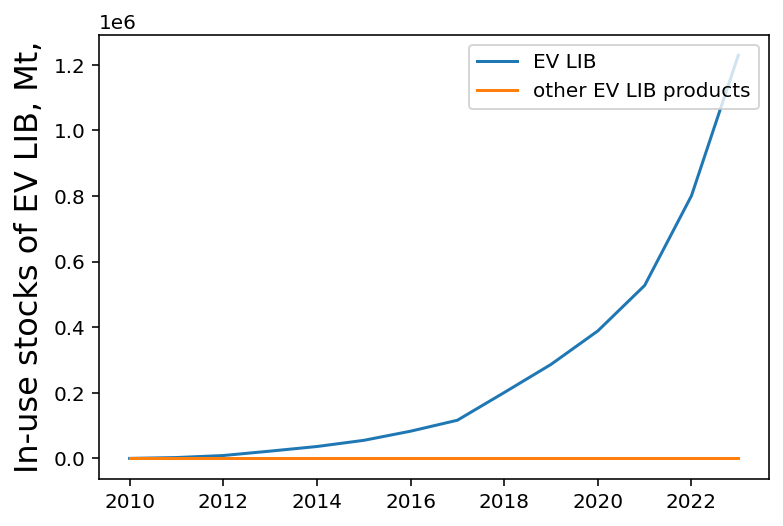

In [316]:
MyColorCycle = pylab.cm.Paired(np.arange(0,1,0.1)) # select 10 colors from the 'Paired' color map.
fig, ax = plt.subplots()
ax.plot(MaTrace_System.IndexTable['Classification']['Time'].Items, 
            np.einsum('tcgme->tg',MaTrace_System.StockDict[ 'S_1'].Values)) 
ax.set_ylabel('In-use stocks of EV LIB, Mt,',fontsize =16)
ax.legend(MaTrace_System.IndexTable['Classification']['Good'].Items, loc='upper right',prop={'size':10})

Text(0, 0.5, 'Landfill stocks of lithium, Mt,')

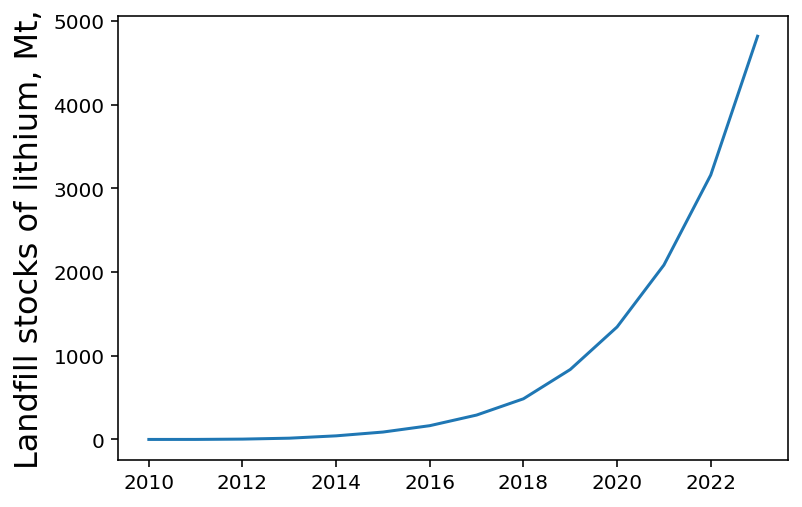

In [317]:
# JV changes: plot LF stock
MyColorCycle = pylab.cm.Paired(np.arange(0,1,0.1)) # select 10 colors from the 'Paired' color map.
fig, ax = plt.subplots()
ax.plot(MaTrace_System.IndexTable['Classification']['Time'].Items, 
            MaTrace_System.StockDict[ 'S_3'].Values) 
ax.set_ylabel('Landfill stocks of lithium, Mt,',fontsize =16)
#ax.legend(MaTrace_System.IndexTable['Classification']['Element'].Items, loc='upper right',prop={'size':10})

The steel stock in vehicles remains stable for a few years and then quickly declines as the vehicles reach their typical lifetime (ca. 15 years). According to the model parameters (remelting yield), the recovered steel shred from vehicles is down-cycled (cascaded) into construction type steel, which in this dataset is used for both construction and machinery. (To have more realistic depictions of the steel cycle, one can introduce more steel categories, but that also increases the data need). Due to the longer lifetime of steel in construction, steel tends to accumulate there, including steel that was first cascaded into machinery and then into buildings. Ultimately, steel stocks slowly decline due to the recovery and remelting losses that occur every time the steel is remelted into new rebars or steel girders. In remelting alone, ca. 6% of the metal are lost to slag each time, and to reduce both these losses and the associated energy demand, steel can be re-used instead of remelted. The re-use strategy is described in detail in the 2012 book "Sustainable Materials - With Both Eyes Open" by Allwood and colleagues (http://www.withbotheyesopen.com/).

To answer RQ2, let's plot the total stock as the sum of the four curves above.

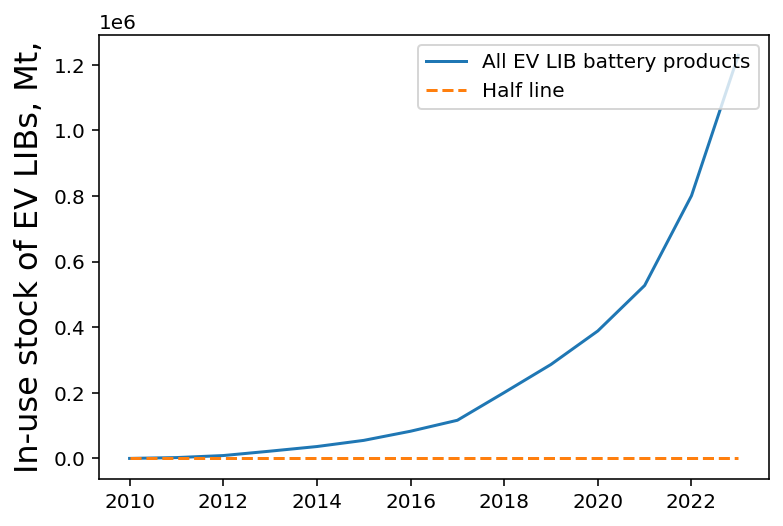

In [318]:
plt.set_loglevel("info") 

HalfLine = 0.5 * MaTrace_System.StockDict[ 'S_1'].Values[0,:,:,:,:].sum()

MyColorCycle = pylab.cm.Paired(np.arange(0,1,0.1)) # select 10 colors from the 'Paired' color map.
fig, ax = plt.subplots()
ax.plot(MaTrace_System.IndexTable['Classification']['Time'].Items, 
            np.einsum('tcgme->t',MaTrace_System.StockDict[ 'S_1'].Values)) 
ax.plot(MaTrace_System.IndexTable['Classification']['Time'].Items, 
            HalfLine * np.ones(len(MaTrace_System.IndexTable['Classification']['Time'].Items)), linestyle = '--') 
ax.set_ylabel('In-use stock of EV LIBs, Mt,',fontsize =16)
ax.legend(['All EV LIB battery products','Half line'], loc='upper right',prop={'size':10})

We see that around a bit before the year 2200, ca. 175 years after the initial consumption in 2020, only half of the steel remains in useful applications in the technosphere. The technical half-life of the steel is thus ca. 175 years.
Given that the climate impacts of current steel production will persist for much longer, one can conclude that such a metal use pattern is not sustainable.

Another question, which is not addressed here, is how tramp elements accumulate in the steel and reduce its quality, especially copper and tin. This topic is addressed by a recent publication by Daehn et al. (2017), DOI 10.1021/acs.est.7b00997.

The code here shows how a systematic MFA model can be set up to answer these types of question. This tutorial illustrates the use of the ODYM functions and data format for material tracing questions, its main emphasis is therefore on the technical aspects of the modelling. The questions posed here can be addressed with simpler models, e.g., models based in Excel. Once the approach becomes more detailed, however, e.g., when other elements, scenarios, and multiple regions are included, the hand-wired approaches will quickly reach their limits, and a systematic approach like the one presented here will prove very powerful.

## 7) Save data and results
Save entire system: 

In [319]:
pickle.dump( {'MaTrace_System': MaTrace_System}, open( "Tutorial6_MaTrace_SystemLL.p", "wb" ) )